# M5 - HMM Regime-Switching HAR : quand la sophistication structurelle nuit

**L'extension la plus faible du pipeline vol** -- apres M12 (OLS deploye), M4 (DLinear 5/21
BEATS), M15 (LSTM keeper), M9 (TFT 0/6 BEATS, surparametrage DL), ce notebook documente un
echec d'une *autre nature* : la sophistication **structurelle** (pas neuronale).

L'idee est seduisante : la volatilite crypto alterne regimes calmes et turbulents. Un modele
qui **adapte ses coefficients HAR au regime courant** (detecte par une chaine de Markov cachee,
HMM K=2 decalee par Viterbi sur le log-RV) pourrait capturer cette asymetrie. C'est l'HAR
**conditionnel au regime** : 8 coefficients OLS (4 base + 4 termes d'interaction regime) au
lieu des 3 du HAR classique.

**Verdict : 1/6 BEATS** -- seul ETH a h=1 beneficie du regime-switching (+9.6% MSE, 4/4 seeds
p<0.005). Plus inquietant : aux **horizons longs (h=5, h=10) le modele est activement nuisible**,
JUSQU'A -53% de MSE en plus vs HAR classique. La sophistication ajoutee n'est pas neutre --
elle degrade les previsions multi-step. La lecon : **sur ces donnees, le HAR a 3 parametres
reste superieur au HAR-HMM a 8 coefficients + decodage**.

Ce grain complete la courbe d'expressivite sous un angle orthogonal au DL : ce n'est pas
seulement le reseau de neurones qui surcompile (M9), l'augmentation structurelle d'un OLS
simple nuit aussi.

> **Fiche technique complete** : [`docs/M5_HMM_REGIME.md`](docs/M5_HMM_REGIME.md). **Script** :
> `scripts/hmm_regime_vol.py`. **Resultats** : Cycle 25 Wave 3, 6 configs x 4 seeds, 576s.

## 1. Chargement des resultats

Resultats pre-calcules (6 configs : BTC/ETH x h=1/5/10, 4 seeds pour l'init HMM, walk-forward
5-fold expanding, refit tous les 22 jours). Le fichier contient deux types de lignes :
**24 per-seed** (un verdict DM par graine) et **6 aggregates** (verdict final par config,
BEATS exige 4/4 seeds). La metrique est le **MSE sur log-RV** compare via test de
Diebold-Mariano (HAC) au HAR classique.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open(Path('scripts/results/m5_hmm_regime.json')) as f:
    data = json.load(f)

all_rows = pd.DataFrame(data['results'])
per_seed = all_rows[all_rows['seed'] != 'aggregate'].copy()
agg = all_rows[all_rows['seed'] == 'aggregate'].copy()
per_seed['seed'] = per_seed['seed'].astype(int)

print(f'Model: HMM Regime-Switching HAR (Hamilton 1989 + Corsi 2009)')
print(f'Approche: {data["approach"]}')
print(f'HMM: K={data["n_hmm_states"]} etats Gaussiens, decodage Viterbi sur log-RV')
print(f'Coefficients: 8 (4 base HAR + 4 termes interaction regime) vs 3 pour le HAR classique')
print(f'Seeds HMM: {data["seeds"]} (init) | Horizons: {data["horizons"]} | WF {data["n_splits"]}-fold, refit {data["refit_every"]}j')
print(f'Lignes par graine: {len(per_seed)} (2 coins x 3 horizons x {len(per_seed)//6} par config) | Aggregates: {len(agg)}')
print(f'Runtime original: {data["elapsed_seconds"]:.0f}s')
print(f'Metrique: MSE sur log-RV + test Diebold-Mariano (HAC) vs HAR classique (baseline M3/M12)')

Model: HMM Regime-Switching HAR (Hamilton 1989 + Corsi 2009)
Approche: regime-switching: separate HAR per Viterbi-decoded regime
HMM: K=2 etats Gaussiens, decodage Viterbi sur log-RV
Coefficients: 8 (4 base HAR + 4 termes interaction regime) vs 3 pour le HAR classique
Seeds HMM: [0, 7, 42, 99] (init) | Horizons: [1, 5, 10] | WF 5-fold, refit 22j
Lignes par graine: 24 (2 coins x 3 horizons x 4 par config) | Aggregates: 6
Runtime original: 576s
Metrique: MSE sur log-RV + test Diebold-Mariano (HAC) vs HAR classique (baseline M3/M12)


## 2. Verdict global : 1/6 BEATS, degrade 4/6 configs

Le regime-switching ne bat le HAR classique que sur **ETH a h=1** (1/6, le seul BEATS au
verdict brut 4/4 seeds). Les 5 autres configs sont INCONCLUSIVES au verdict aggregate (la
convention du JSON : BEATS exige 4/4 seeds, sinon INCONCLUSIVE). Mais le detail compte :
**4 de ces 5 configs INCONCLUSIVES ont une reduction MSE negative** (le modele fait *pire*
que le HAR classique), dont 3 avec **0 graine sur 4** qui BEATS. Le doc M5 qualifie ces
dernieres de "BEATEN BY" -- le regime-switching n'est pas simplement inutile, il **degrade
la prevision** aux horizons longs.

In [2]:
n_beats = int((agg['aggregate_verdict'] == 'BEATS').sum())
n_inc = int((agg['aggregate_verdict'] == 'INCONCLUSIVE').sum())
# Interpretation derivee (fidele aux donnees brutes) : INCONCLUSIVE + reduction negative = degrade
n_degrade = int(((agg['aggregate_verdict']=='INCONCLUSIVE') & (agg['mean_reduction_pct'] < 0)).sum())
n_zero_seed = int(((agg['n_beats_seeds']=='0/4') & (agg['mean_reduction_pct'] < 0)).sum())
print('=== Verdict global HMM-Regime vs HAR classique (previsions MSE) ===')
print()
print(f'BEATS (verdict brut, 4/4 seeds)       : {n_beats}/6')
print(f'INCONCLUSIVE (verdict brut)           : {n_inc}/6')
print(f'  dont reduction MSE negative (degrade): {n_degrade}/6')
print(f'  dont 0/4 seeds BEATS (nettement pire): {n_zero_seed}/6')
print()
print('Table per-config (verdict aggregate brut + interpretation) :')
print(f'{"config":<10} {"regime_MSE":<11} {"classic_MSE":<12} {"reduction":<10} {"seeds":<8} {"interp"}')
print('-' * 72)
for _, r in agg.sort_values(['coin','horizon']).iterrows():
    interp = r['aggregate_verdict']
    if r['aggregate_verdict']=='INCONCLUSIVE' and r['mean_reduction_pct'] < 0:
        interp = 'DEGRADE' if r['n_beats_seeds']=='0/4' else 'legerement pire'
    coin = r['coin'].replace('-USD','')
    print(f'{coin+" h="+str(int(r["horizon"])):<10} {r["mean_regime_mse"]:.3f}      {r["mean_classic_mse"]:.3f}       {r["mean_reduction_pct"]:+6.1f}%   {r["n_beats_seeds"]:<8} {interp}')
print()
print('Note honnete : le verdict brut du JSON ne code que BEATS/INCONCLUSIVE.')
print('L interpretation DEGRADE (red < 0) est derivee des donnees, en accord avec le doc M5.')

=== Verdict global HMM-Regime vs HAR classique (previsions MSE) ===

BEATS (verdict brut, 4/4 seeds)       : 1/6
INCONCLUSIVE (verdict brut)           : 5/6
  dont reduction MSE negative (degrade): 4/6
  dont 0/4 seeds BEATS (nettement pire): 4/6

Table per-config (verdict aggregate brut + interpretation) :
config     regime_MSE  classic_MSE  reduction  seeds    interp
------------------------------------------------------------------------
BTC h=1    0.825      0.888         +7.0%   3/4      INCONCLUSIVE
BTC h=5    0.580      0.522        -11.1%   0/4      DEGRADE
BTC h=10   0.732      0.571        -28.3%   0/4      DEGRADE
ETH h=1    0.619      0.684         +9.6%   4/4      BEATS
ETH h=5    0.441      0.374        -17.9%   0/4      DEGRADE
ETH h=10   0.573      0.375        -53.0%   0/4      DEGRADE

Note honnete : le verdict brut du JSON ne code que BEATS/INCONCLUSIVE.
L interpretation DEGRADE (red < 0) est derivee des donnees, en accord avec le doc M5.


## 3. La degradation croissante avec l'horizon (finding cle)

C'est le resultat le plus important du notebook. La reduction MSE vs HAR classique est
**positive a h=1** (le regime aide, surtout ETH) mais devient **fortement negative aux
horizons longs** (jusqu'a -53% a ETH h=10 = le modele ajoute plus de la moitie d'erreur en
plus). La raison technique (cf doc finding #5) : la prevision h-step iterer utilise un
**unique indicateur de regime R pour TOUTES les etapes** de la fenetre de prevision -- mais
le regime peut **switcher** en cours de prevision. Le modele ne peut pas s'adapter
mid-forecast, et les termes d'interaction accumulent l'erreur.

=== Reduction MSE vs HAR classique, par horizon (moyenne 2 coins) ===

horizon    BTC            ETH            moyenne
h=1           +7.0%          +9.6%         +8.3%
h=5          -11.1%         -17.9%        -14.5%
h=10         -28.3%         -53.0%        -40.7%


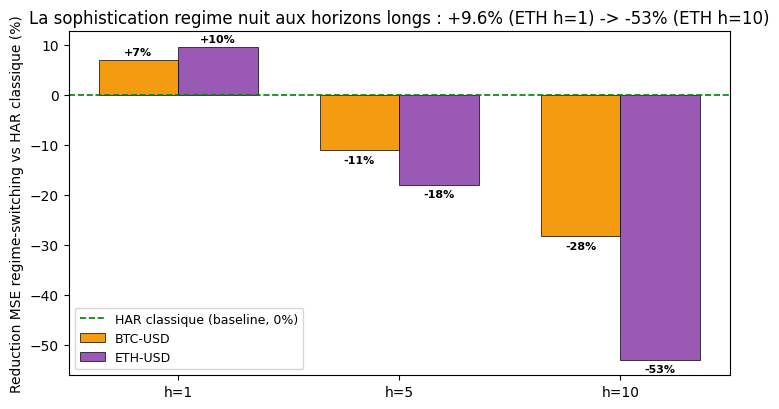

Vert = le regime bat HAR. h=1 legerement positif (ETH +9.6%) ; h=5/h=10 fortement negatif (degrade).


In [3]:
print('=== Reduction MSE vs HAR classique, par horizon (moyenne 2 coins) ===')
print()
print(f'{"horizon":<10} {"BTC":<14} {"ETH":<14} {"moyenne"}')
for h in [1, 5, 10]:
    b = agg[(agg['coin']=='BTC-USD') & (agg['horizon']==h)]['mean_reduction_pct'].iloc[0]
    e = agg[(agg['coin']=='ETH-USD') & (agg['horizon']==h)]['mean_reduction_pct'].iloc[0]
    print(f'h={h:<8} {b:+7.1f}%       {e:+7.1f}%       {(b+e)/2:+6.1f}%')

fig, ax = plt.subplots(figsize=(7.5, 4.2))
horizons = [1, 5, 10]
btc = [agg[(agg['coin']=='BTC-USD') & (agg['horizon']==h)]['mean_reduction_pct'].iloc[0] for h in horizons]
eth = [agg[(agg['coin']=='ETH-USD') & (agg['horizon']==h)]['mean_reduction_pct'].iloc[0] for h in horizons]
x = np.arange(len(horizons))
w = 0.36
bars_b = ax.bar(x - w/2, btc, w, label='BTC-USD', color='#f39c12', edgecolor='k', linewidth=0.5)
bars_e = ax.bar(x + w/2, eth, w, label='ETH-USD', color='#9b59b6', edgecolor='k', linewidth=0.5)
ax.axhline(0, color='green', linewidth=1.2, linestyle='--', label='HAR classique (baseline, 0%)')
ax.set_xticks(x); ax.set_xticklabels([f'h={h}' for h in horizons])
ax.set_ylabel('Reduction MSE regime-switching vs HAR classique (%)')
ax.set_title('La sophistication regime nuit aux horizons longs : +9.6% (ETH h=1) -> -53% (ETH h=10)')
for bars in (bars_b, bars_e):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height() + (1 if b.get_height()>=0 else -2.5),
                f'{b.get_height():+.0f}%', ha='center', fontsize=8, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()
print('Vert = le regime bat HAR. h=1 legerement positif (ETH +9.6%) ; h=5/h=10 fortement negatif (degrade).')

## 4. La sensibilite a l'initialisation HMM (finding #4)

Pourquoi le verdict est-il si instable ? Le decodage Viterbi de l'HMM depend fortement de
l'initialisation (les seeds). Le doc finding #4 note : « la graine 0 et 99 peuvent classer
60%/40% bas/haut, tandis que la graine 7 produit 80%/20% ». Cette variance se traduit
directement en instabilite de prevision. Le graphique ci-dessous montre la dispersion de la
reduction MSE **par graine** : meme sur ETH h=1 (le seul BEATS), une graine produit un edge
quasi-nul.

=== Dispersion de la reduction MSE par graine (24 per-seed rows) ===

config     seeds BEATS  reduction par graine (%)                
USD h=1    3/4         [+10.0  +0.1  +8.3  +9.6]
USD h=5    0/4         [-15.3  -0.8  -4.1 -24.4]
USD h=10   0/4         [-40.5  -1.4 -15.4 -55.8]
USD h=1    4/4         [ +9.5 +11.0  +6.2 +11.7]
USD h=5    0/4         [-20.3 -20.5 -11.3 -19.7]
USD h=10   0/4         [-53.6 -74.4 -32.9 -51.1]


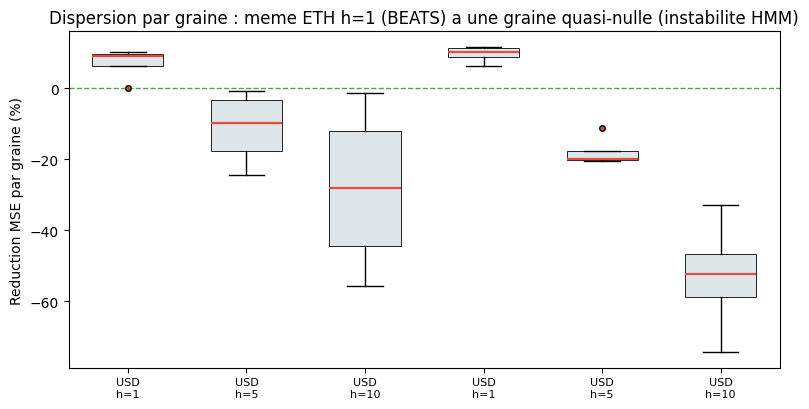

Boite = dispersion inter-graines (4 points). Barre rouge = mediane. La boite etendue = sensibilite HMM.


In [4]:
print('=== Dispersion de la reduction MSE par graine (24 per-seed rows) ===')
print()
print(f'{"config":<10} {"seeds BEATS":<12} {"reduction par graine (%)":<40}')
for (coin, h), grp in per_seed.groupby(['coin','horizon']):
    reds = grp.sort_values('seed')['mse_reduction_pct'].values
    seeds_str = ' '.join(f'{r:+5.1f}' for r in reds)
    n_b = int((grp['dm_verdict']=='BEATS baseline').sum())
    lbl = coin[-3:].strip()[-3:] + f' h={h}'
    print(f'{lbl:<10} {n_b}/4         [{seeds_str}]')

fig, ax = plt.subplots(figsize=(8, 4.2))
labels = []
positions = []
data_box = []
i = 0
for (coin, h), grp in per_seed.groupby(['coin','horizon']):
    reds = grp['mse_reduction_pct'].values
    data_box.append(reds)
    positions.append(i)
    labels.append(f'{coin[-3:].strip()}\nh={h}')
    i += 1
bp = ax.boxplot(data_box, positions=positions, widths=0.6, patch_artist=True,
                boxprops=dict(facecolor='#dfe6e9', edgecolor='k', linewidth=0.6),
                medianprops=dict(color='#e74c3c', linewidth=1.6),
                flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=4))
ax.axhline(0, color='green', linewidth=1.0, linestyle='--', alpha=0.7)
ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Reduction MSE par graine (%)')
ax.set_title('Dispersion par graine : meme ETH h=1 (BEATS) a une graine quasi-nulle (instabilite HMM)')
plt.tight_layout()
plt.show()
print('Boite = dispersion inter-graines (4 points). Barre rouge = mediane. La boite etendue = sensibilite HMM.')

## 5. Synthese : deux axes d'echec, une meme lecon

Le pipeline vol echoue a battre le HAR simple par **deux axes distincts** de sophistication,
et la conclusion est identique : **ajouter de la complexite n'aide pas sur ces donnees**.

### Axe 1 : expressivite neuronale (DL)

| Modele | Params | Angle | Verdict | Notebook |
|--------|--------|-------|---------|----------|
| M12 HAR-RV-J (OLS) | 7 | strategie | BEATS, **deploye** | [m12](m12_har_rv_j_research.ipynb) |
| M4 DLinear | ~22 | prevision (MSE) | 5/21 BEATS (BTC) | [m4](m4_dlinear_vol_research.ipynb) |
| M15 Log-LSTM h=32 | 4 769 | strategie | BEATS, keeper non-deploye | [m15](m15_lstm_rv_research.ipynb) |
| M9 TFT | ~110K | prevision (DirAcc) | 0/6 BEATS (overfit DL) | [m9](m9_tft_vol_research.ipynb) |

### Axe 2 : sophistication structurelle (OLS augmente)

| Modele | Params | Verdict | Notebook |
|--------|--------|---------|----------|
| M3b HAR asymetrique (semivariance) | 5 | 3/21 BEATS (BTC) | (doc) |
| **M5 HAR-HMM regime** | **8 + HMM** | **1/6 BEATS, nuisible h>=5** | **ce notebook** |

M5 est le **maillon structurel** de l'echec : meme sans reseau de neurones, decomposer le HAR
par regime ajoute du bruit (termes d'interaction) qui compunde sur les horizons longs. Le DL
(M9) surcompile par *capacite* ; le HAR-HMM (M5) surcompile par *structure*. Les deux
concluent que le **HAR a 3 coefficients reste le meilleur compromis** sur ce benchmark crypto,
et que le modele le plus simple (M12 OLS, 7 parametres) est le seul a atteindre la production.

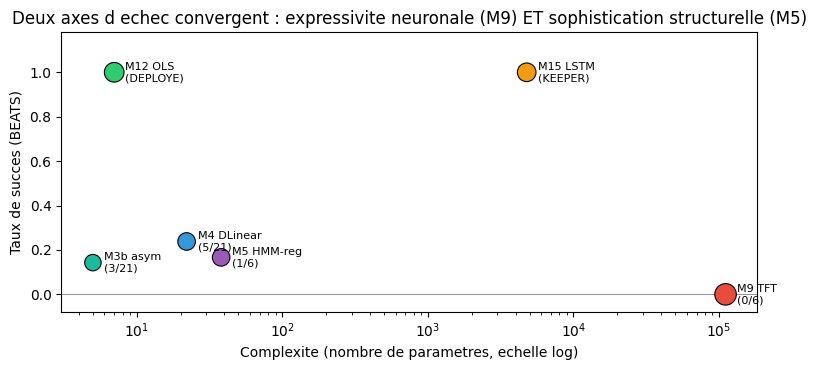

Vert = deploye (M12). Rouge = 0/6 (M9). Violet = nuisible h>=5 (M5). La complexite ne paie pas.


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.8))
models = ['M12 OLS', 'M3b asym', 'M4 DLinear', 'M15 LSTM', 'M5 HMM-reg', 'M9 TFT']
params = [7, 5, 22, 4769, 8 + 30, 110801]  # M5 = 8 coeff + HMM params approx
beats_count = [1.0, 3/21, 5/21, 1.0, 1/6, 0/6]  # deployed/keeper normalized a 1.0
beats_lbl = ['DEPLOYE', '3/21', '5/21', 'KEEPER', '1/6', '0/6']
colors = ['#2ecc71', '#1abc9c', '#3498db', '#f39c12', '#9b59b6', '#e74c3c']
ax.scatter(params, beats_count, s=[200,140,160,180,160,240], c=colors, edgecolor='k', linewidth=0.8, zorder=3)
for i, (m, p, b, l) in enumerate(zip(models, params, beats_count, beats_lbl)):
    yoff = 0.05 if b < 0.6 else -0.08
    ax.annotate(f'{m}\n({l})', (p, b), xytext=(8, 0), textcoords='offset points', fontsize=8, va='center')
ax.set_xscale('log')
ax.set_ylim(-0.08, 1.18)
ax.set_xlabel('Complexite (nombre de parametres, echelle log)')
ax.set_ylabel('Taux de succes (BEATS)')
ax.set_title('Deux axes d echec convergent : expressivite neuronale (M9) ET sophistication structurelle (M5)')
ax.axhline(0, color='gray', linewidth=0.6)
plt.tight_layout()
plt.show()
print('Vert = deploye (M12). Rouge = 0/6 (M9). Violet = nuisible h>=5 (M5). La complexite ne paie pas.')

## 6. Lecon : ne pas confondre richer features et meilleur modele

L'echec du HAR-HMM regime est pedagogiquement subtil. Le modele part d'une **intuition
economique solide** (les regimes de volatilite existent, BTC alterne calmes et tempetes),
l'implemente correctement (HMM standard, Viterbi, OLS avec interactions), et echoue quand
meme. Pourquoi ?

1. **Le HAR capte deja les regimes implicitement.** Ses moyennes mobiles 1j/5j/22j reagissent
   aux changements de volatilite -- la decomposition regime est en partie redondante avec la
   structure temporelle que le HAR encode deja.
2. **Les termes d'interaction ajoutent du bruit sur des donnees limitees.** Estimer 8
   coefficients sur 2 ans de donnees ETH revient a diviser le signal par regime -- chaque
   sous-modele a encore moins de donnees. C'est la meme loi qu'au fold 1 du TFT (M9) : moins
   de donnees par parametre = plus d'overfitting, meme pour un OLS.
3. **La prevision multi-step casse l'hypothese de regime stationnaire.** Le defaut fondamental
   (doc finding #5) : un seul R pour toute la fenetre h=10, alors que le regime peut switcher.

### Le fil rouge du pipeline vol

Sur ce benchmark crypto a donnees limitees, **chaque source de complexite ajoutee au HAR
simple a 3 coefficients est un echec** -- qu'elle vienne du DL (M9 TFT, M15 LSTM), de
l'asymetrie (M3b), ou du regime-switching (M5). Le modele OLS a 7 parametres (M12) reste le
seul deploye. Cette convergence de M5, M9 et M15 vers le meme constat est la lecon la plus
robuste de la serie vol : **sur des donnees bruitees et limitees, la parcimonie bat
l'expressivite comme la sophistication.**

### References

- Hamilton, J.D. (1989). *A New Approach to the Economic Analysis of Nonstationary Time
  Series and the Business Cycle*. Econometrica 57(2). (Le papier fondateur des HMM de regime).
- Corsi, F. (2009). *A Simple Approximate Long-Memory Model of Realized Volatility*. (HAR baseline).
- Diebold, F.X. & Mariano, R.S. (1995). *Comparing Predictive Accuracy*. (test DM).
- Pour l'echec parallele du DL : [M9 TFT](m9_tft_vol_research.ipynb). Pour le deployed OLS :
  [M12 HAR-RV-J](m12_har_rv_j_research.ipynb). Fiche technique : [`docs/M5_HMM_REGIME.md`](docs/M5_HMM_REGIME.md).